<a href="https://colab.research.google.com/github/Nounsidev/PyTorch_Learning/blob/main/5_ComputerVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import numpy as np

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [2]:
##1. GETTING A DATASET
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.6MB/s]


In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [5]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

1.2 VISUALIZING DATA


Image Shape: torch.Size([1, 28, 28])


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

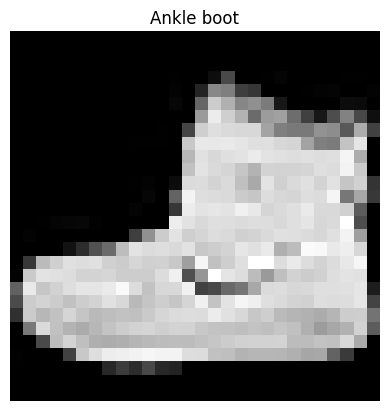

In [6]:
import matplotlib.pyplot as plt

image, label = train_data[0]
print(f"Image Shape: {image.shape}")
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

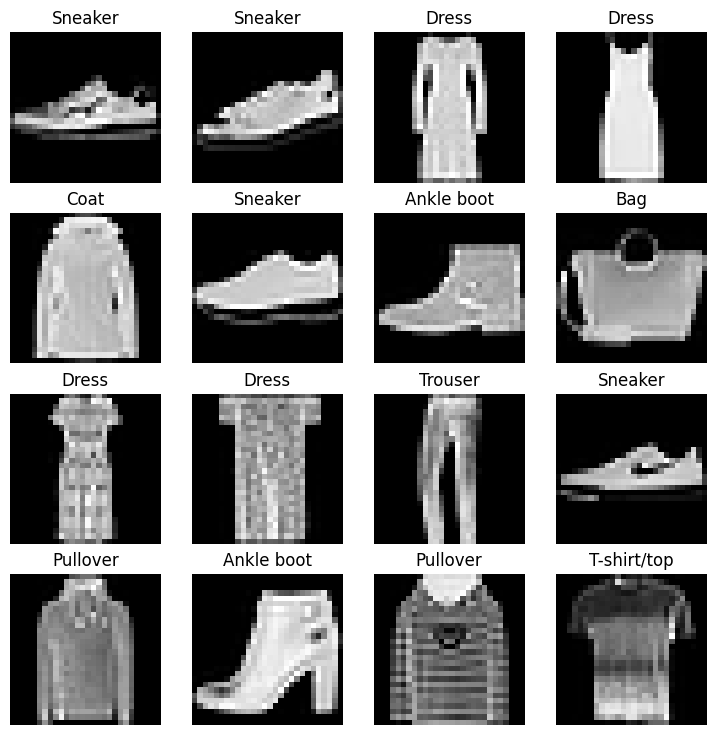

In [7]:
#Plot more images
torch.manual_seed(38)

fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols +1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.title(class_names[label])
  plt.imshow(image.squeeze(), cmap="gray")
  plt.axis(False)

2. PREPARE DATA LOADER

In [8]:
#Split into 32-size batch
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)


train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7e58f12aaa50>,
 <torch.utils.data.dataloader.DataLoader at 0x7e58f074ae90>)

In [9]:
print(f"Dataloaders: {train_dataloader, test_dataloader}")
#

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7e58f12aaa50>, <torch.utils.data.dataloader.DataLoader object at 0x7e58f074ae90>)


In [10]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image Shape: torch.Size([1, 28, 28])
Label: 8, label shape: torch.Size([])


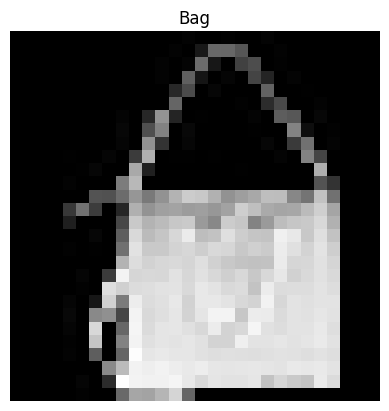

In [11]:
#torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
image, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

print(f"Image Shape: {image.shape}")
print(f"Label: {label}, label shape: {label.shape}")


3. BUILD A BASELINE MODEL

In [12]:
#Create a flatten layer
flatter_model = nn.Flatten()

#Get a single sample
x = train_features_batch[0]

#Flatten the sample
output = flatter_model(x) # perform a forward pass

print(f"Shape before flattening: {x.shape}")
print(f"Shape after flattening: {output.shape}")

Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])


In [13]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)


In [14]:
torch.manual_seed(38)

#Setup model with input parameters
modelV0 = FashionMNISTModelV1(
    input_shape=28*28,
    hidden_units=10,
    output_shape=len(class_names)
).to("cpu")
modelV0

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [15]:
dummy_x = torch.rand([1, 1, 28, 28])
modelV0(dummy_x)

tensor([[ 0.4329,  0.1027, -0.3434, -0.0773,  0.0406,  0.0514,  0.7181,  0.1866,
          0.0195,  0.4578]], grad_fn=<AddmmBackward0>)

In [16]:
# 3.1 SETUP LOSS, OPTIMIZER AND EVALUATION METRICS
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


In [17]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=modelV0.parameters(), lr=0.01)


In [18]:
# 3.2 EXPERIMENTING
from timeit import default_timer as Timer
def print_train_time(start: float, end: float, device: torch.device = None):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [19]:
start_time = Timer()

#Code
end_time = Timer()

print_train_time(start_time, end_time, device= "cpu")


Train time on cpu: 0.000 seconds


3.008099997714453e-05

In [20]:
# 3.3 Creating a training loop and training a model on batches of data
from tqdm.auto import tqdm

#Set the seed and timer
torch.manual_seed(38)
train_time_start_on_cpu = Timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_loss = 0

  for batch, (X, y) in enumerate(train_dataloader):
    modelV0.train()

    #1. Forward Pass
    y_pred = modelV0(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss

    #2. Optimizer Zero Grad
    optimizer.zero_grad()

    #3. Loss Backward
    loss.backward()

    #4. Optimizer Step
    optimizer.step()


    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)

  test_loss, test_acc = 0, 0
  modelV0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      test_pred = modelV0(X_test)
      test_loss += loss_fn(test_pred, y_test)
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim = 1))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

  train_timer_end_on_cpu = Timer()
  total_train_time_modelV0 = print_train_time(start=train_time_start_on_cpu,
                                              end=train_timer_end_on_cpu,
                                              device=str(next(modelV0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.90160 | Test Loss: 0.62825 | Test Acc: 77.96
Train time on cpu: 10.359 seconds
Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.55894 | Test Loss: 0.54485 | Test Acc: 81.24
Train time on cpu: 20.403 seconds
Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.50442 | Test Loss: 0.51660 | Test Acc: 81.84
Train time on cpu: 30.137 seconds


4. SETUP DEVICE AGNOSTIC CODE

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

5. MAKE PREDICTIONS AND GET MODELV0 RESULTS

In [22]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn):
  """Returns a dictionary containing the results of model predicting on data_loader."""

  loss, acc = 0, 0
  model.eval()
  model.to(device)
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)

      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim = 1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

modelV0_results = eval_model(model=modelV0,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)

modelV0_results



  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.5165994167327881,
 'model_acc': 81.83905750798722}

6. MODELV1: BUILDING A NON-LINEARITY MODEL


In [23]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x):
    return self.layer_stack(x)

In [24]:
#Create ModelV1 instance
torch.manual_seed(42)

modelV1 = FashionMNISTModelV1(
    input_shape=28*28,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

modelV1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [25]:
#6.1 Setup loss, optimizer and evalution metric

from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=modelV1.parameters(), lr=0.1)

In [26]:
#6.2 Create testing and training loop function
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0, 0
  model.train()

  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    #1. Forward Pass
    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim = 1))

    #2. Optimizer Zero Grad
    optimizer.zero_grad()

    #3. Loss Backward
    loss.backward()

    #4. Optimizer Step
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}%\n")

In [27]:
def test_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.eval()

  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim = 1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  print(f"Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%\n")

In [28]:
torch.manual_seed(42)

from timeit import default_timer as Timer
train_time_start_on_gpu = Timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(model=modelV1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)
  test_step(model=modelV1,
             data_loader=test_dataloader,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn)
  print("\n-----------------------")

train_time_end_on_gpu = Timer()
total_train_time_modelV1 = print_train_time(train_time_start_on_gpu, train_time_end_on_gpu, device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train Loss: 1.09199 | Train Acc: 61.34%

Test Loss: 0.95636 | Test Acc: 65.00%


-----------------------
Epoch: 1
---------
Train Loss: 0.78101 | Train Acc: 71.93%

Test Loss: 0.72227 | Test Acc: 73.91%


-----------------------
Epoch: 2
---------
Train Loss: 0.67027 | Train Acc: 75.94%

Test Loss: 0.68500 | Test Acc: 75.02%


-----------------------
Train time on cuda: 33.223 seconds


In [29]:
modelV1_results = eval_model(modelV1, test_dataloader, loss_fn, accuracy_fn)
modelV1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [30]:
modelV0_results = eval_model(modelV0, test_dataloader, loss_fn, accuracy_fn)
modelV0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.5165994167327881,
 'model_acc': 81.83905750798722}

6. BUILDING A CONVOLUTIONAL NEURAL NETWORK

In [31]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    #print(f"Output shape of conv_block_1: {x.shape}")
    x = self.conv_block_2(x)
    #print(f"Output shape of conv_block_2: {x.shape}")
    x = self.classifier(x)
    #print(f"Output shape of classifier: {x.shape}")
    return x



In [32]:
modelV2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
modelV2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

7.1 Stepping through nn.Conv2D()

In [33]:
torch.manual_seed(42)

images = torch.randn(size=(32, 3, 64, 64)).to(device)
test_image = images[0]

print(f"Image batch shape: {image.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image: {test_image}")


Image batch shape: torch.Size([1, 28, 28])
Single image shape: torch.Size([3, 64, 64])
Test image: tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978

In [34]:
test_image.shape

torch.Size([3, 64, 64])

In [35]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=0).to(device)

conv_ouput = conv_layer(test_image.unsqueeze(dim=0))
conv_ouput

tensor([[[[-2.8778e-01, -6.0596e-02, -5.6306e-02,  ...,  2.8654e-01,
            6.6224e-01, -2.3216e-01],
          [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
           -1.8552e-01, -5.7622e-01],
          [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
            1.4923e-01,  1.4236e-01],
          ...,
          [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
            4.2594e-01, -4.8341e-01],
          [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
           -3.6626e-01,  3.5645e-01],
          [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
           -4.9680e-01, -7.2258e-01]],

         [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
           -1.7643e+00,  2.5263e-01],
          [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
            4.8068e-01,  8.4869e-01],
          [ 6.4927e-01, -4.2061e-03, -4.9991e-01,  ...,  5.8356e-01,
            2.4611e-01,  6.6233e-01],
          ...,
     

### 7.2 Stepping through `nn.MaxPool2D()`

In [36]:
test_image.shape

torch.Size([3, 64, 64])

In [37]:
print(f"Test image original shape: {test_image.shape}\n")
print(f"Test image unsqueezed shape: {test_image.unsqueeze(dim=0).shape}\n")

max_pool_layer = nn.MaxPool2d(kernel_size=2).to(device)

test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Test image through conv layer shape: {test_image_through_conv.shape}\n")

test_image_output = max_pool_layer(test_image_through_conv)
print(f"Test image through max pool layer shape: {test_image_output.shape}")

Test image original shape: torch.Size([3, 64, 64])

Test image unsqueezed shape: torch.Size([1, 3, 64, 64])

Test image through conv layer shape: torch.Size([1, 10, 62, 62])

Test image through max pool layer shape: torch.Size([1, 10, 31, 31])


In [38]:
torch.manual_seed(42)

random_tensor = torch.randn(size=(1, 1, 2, 2))

max_pool_layer = nn.MaxPool2d(kernel_size=2)

random_tensor, max_pool_layer(random_tensor)


(tensor([[[[0.3367, 0.1288],
           [0.2345, 0.2303]]]]),
 tensor([[[[0.3367]]]]))

In [39]:
rand_img_tensor = torch.randn(size=(1, 28, 28))
modelV2(rand_img_tensor.unsqueeze(dim=0).to(device))

tensor([[-0.0098, -0.0206, -0.0009, -0.0539,  0.0547,  0.0526, -0.0558, -0.0297,
         -0.0414, -0.0737]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.3 SETUP LOSS FUNC AND OPTIMIZER


In [40]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=modelV2.parameters(), lr=0.1)

In [41]:
modelV2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[-0.0941, -0.2004,  0.0315],
                        [-0.3292,  0.3010, -0.2832],
                        [ 0.2573,  0.0555, -0.1082]]],
              
              
                      [[[ 0.2060,  0.0520,  0.2693],
                        [ 0.0364, -0.1051,  0.0896],
                        [-0.0904,  0.1403,  0.2976]]],
              
              
                      [[[ 0.1927, -0.1457,  0.1924],
                        [ 0.0596,  0.1693, -0.2032],
                        [-0.3300, -0.1288, -0.2557]]],
              
              
                      [[[ 0.2735,  0.0960,  0.1381],
                        [ 0.1054, -0.0058,  0.2609],
                        [-0.2368,  0.0210, -0.2275]]],
              
              
                      [[[ 0.1028, -0.1148,  0.1021],
                        [-0.0694,  0.2765, -0.1976],
                        [-0.1988, -0.1988,  0.2998]]],
              
              
      

In [42]:
from timeit import default_timer as Timer
train_time_start_on_gpu = Timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n----------")
  train_step(model=modelV2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)

  test_step(model=modelV2,
             data_loader=test_dataloader,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn)

  train_time_end_on_gpu = Timer()
  total_train_time_modelV2 = print_train_time(start=train_time_start_on_gpu, end=train_time_end_on_gpu, device=str(next(modelV2.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
----------
Train Loss: 0.60314 | Train Acc: 78.00%

Test Loss: 0.41173 | Test Acc: 84.96%

Train time on cuda:0: 13.221 seconds
Epoch: 1
----------
Train Loss: 0.35706 | Train Acc: 87.10%

Test Loss: 0.37228 | Test Acc: 86.53%

Train time on cuda:0: 25.804 seconds
Epoch: 2
----------
Train Loss: 0.32321 | Train Acc: 88.36%

Test Loss: 0.34614 | Test Acc: 87.59%

Train time on cuda:0: 38.716 seconds


In [47]:
modelV2_results = eval_model(modelV2, test_dataloader, loss_fn, accuracy_fn)
modelV2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.34614449739456177,
 'model_acc': 87.58985623003196}

### 8. COMPARE MODEL RESULTS AND TRAINING TIME

In [53]:
import pandas as pd
compare_results = pd.DataFrame([modelV0_results,
                               modelV1_results,
                               modelV2_results])

compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV1,0.516599,81.839058
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.346144,87.589856


In [54]:
#Add training time to results comparison
compare_results["training_time"] = [total_train_time_modelV0,
                                          total_train_time_modelV1,
                                          total_train_time_modelV2]

compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV1,0.516599,81.839058,30.137142
1,FashionMNISTModelV1,0.685001,75.019968,33.223339
2,FashionMNISTModelV2,0.346144,87.589856,38.715752


Text(0, 0.5, 'Model')

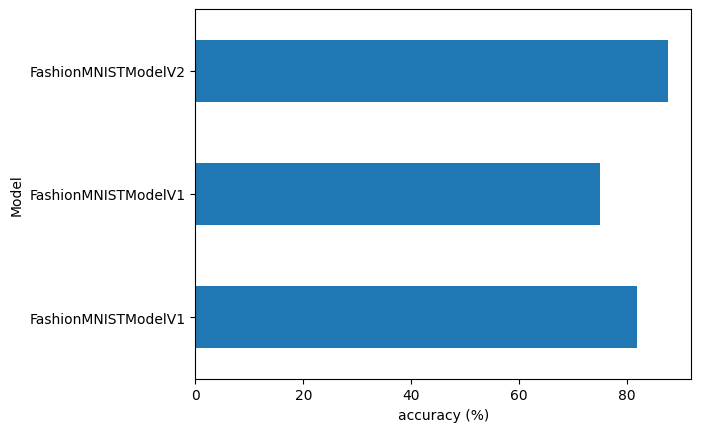

In [57]:
# Visualize our models result
compare_results.set_index("model_name")["model_acc"].plot(kind = "barh")
plt.xlabel("accuracy (%)")
plt.ylabel("Model")


### 9. MAKE AND EVALUATE RANDOM PREDICTION WITH MODELV2

In [61]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for sample in data:

      sample = torch.unsqueeze(sample,0).to(device)
      pred_logit = model(sample)

      #Get pred prob
      pred_prob = torch.softmax(pred_logit.squeeze(), 0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)


In [81]:
import random


test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k = 9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape


torch.Size([1, 28, 28])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

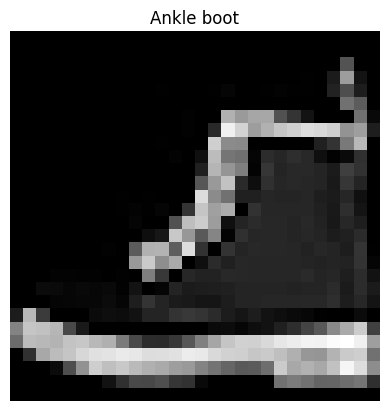

In [76]:
plt.imshow(test_samples[0].squeeze(), cmap = "gray")
plt.title(class_names[test_labels[0]])
plt.axis("off")

In [82]:
pred_probs = make_predictions(modelV2, test_samples)


pred_probs[:2]

tensor([[7.6858e-02, 6.5057e-03, 4.5073e-01, 2.8242e-02, 3.2730e-01, 5.3230e-04,
         3.1270e-02, 7.3063e-05, 7.8074e-02, 4.1130e-04],
        [6.1782e-04, 1.4576e-05, 1.2454e-01, 1.1879e-04, 8.6996e-01, 5.1082e-07,
         4.3836e-03, 4.8606e-07, 3.5288e-04, 4.1722e-06]])

In [83]:
#Convert pred prob to label
pred_classes = pred_probs.argmax(1)
pred_classes

tensor([2, 4, 4, 3, 2, 2, 0, 1, 1])

In [79]:
test_labels

[9, 7, 2, 0, 1, 0, 4, 5, 4]

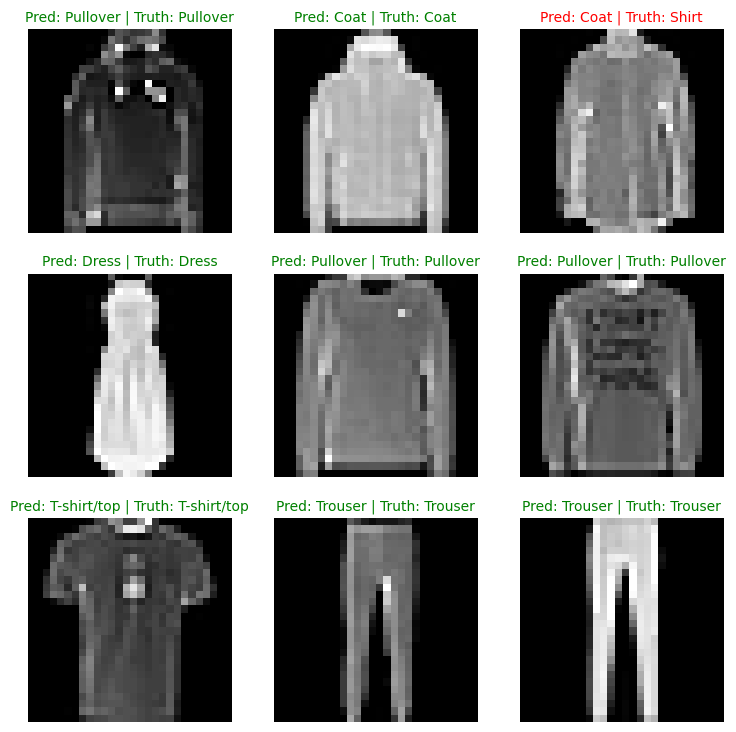

In [84]:
# Plot prediction

plt.figure(figsize=(9,9))
nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):

  plt,plt.subplot(nrows, ncols, i+1)

  plt.imshow(sample.squeeze(), cmap ="gray")

  pred_label = class_names[pred_classes[i]]

  truth_label = class_names[test_labels[i]]

  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, fontsize = 10, color = "green")
  else:
    plt.title(title_text, fontsize = 10, color = "red")

  plt.axis("off")

### 3. MAKING A CONFUSION MATRIX FOR FURTHER PREDICTION EVALUATION


In [88]:
#Make predictions with trained model
y_preds = []

modelV2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader):
    X, y = X.to(device), y.to(device)

    y_logit = modelV2(X)
    y_pred = torch.softmax(y_logit.squeeze(), 0).argmax(dim = 1)
    y_preds.append(y_pred.cpu())

#print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor


  0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 0])

In [89]:
try:
  import torchmetrics, mlxtend
  print(f"torchmetrics version: {torchmetrics.__version__}")
  print(f"mlxtend version: {mlxtend.__version__}")
except:
  !pip install torchmetrics mlxtend
  import torchmetrics, mlxtend


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.9 MB/s eta 0:00:00


In [90]:
mlxtend.__version__

'0.23.4'

In [97]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

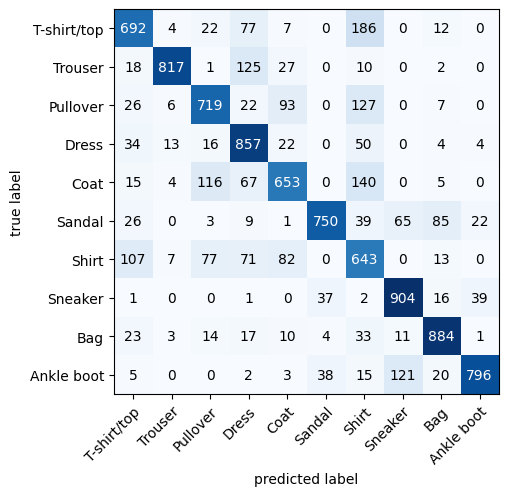

In [100]:
#Set up an instance
confmat = ConfusionMatrix(task="multiclass",num_classes=len(class_names))
confmat_tensor = confmat(preds = y_pred_tensor, target = test_data.targets)

#Plot confmat
fig, ax = plot_confusion_matrix(conf_mat = confmat_tensor.numpy(),
                                class_names= class_names,
                                figsize=(9,5))

### 11. SAVE AND LOAD BEST PERFORMING MODEL


In [102]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

MODEL_NAME = "05_fashion_mnist_model_v2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(modelV2.state_dict(), MODEL_SAVE_PATH)

Saving model to: models/05_fashion_mnist_model_v2.pth


In [103]:
#Load Model
torch.manual_seed(42)

loaded_modelV2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names))
loaded_modelV2.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_modelV2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [104]:
modelV2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.34614449739456177,
 'model_acc': 87.58985623003196}

In [106]:
torch.manual_seed(42)

loaded_modelV2_results = eval_model(loaded_modelV2, test_dataloader, loss_fn, accuracy_fn)

loaded_modelV2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.34614449739456177,
 'model_acc': 87.58985623003196}